# Crop Classification with Sentinel-2 + CDL (California & Arkansas)

Reproducing the methodology from:

> *"A lightweight CNN-Transformer network for pixel-based crop mapping using time-series Sentinel-2 imagery"*

**Study areas:** Sacramento Valley, CA · Arkansas Delta, AR  
**Sensor:** Sentinel-2 SR (COPERNICUS/S2_SR_HARMONIZED)  
**Labels:** USDA Cropland Data Layer (CDL)  
**Model:** MCTNet — Multi-scale CNN-Transformer  


---
## Step 1 · Literature Review

### Methodology summary

| Aspect | Description |
|--------|-------------|
| **Data** | Sentinel-2 SR 10 m, selected bands; USDA CDL 30 m crop-type raster |
| **Study areas** | Sacramento Valley (CA) and Mississippi Delta (AR), year 2020–2021 |
| **Temporal sampling** | Monthly median composites (12 time-steps) after cloud masking |
| **Preprocessing** | QA60 cloud mask → divide by 10 000 (reflectance) → linear interpolation of missing values → per-sample min-max normalisation |
| **Vegetation indices** | NDVI, EVI, SAVI appended as extra channels |
| **Architecture** | Three cascaded CNN-Transformer stages; each stage: Conv1D → BN → ReLU → TransformerEncoderLayer → MaxPool1D(2); final MLP classifier |
| **Training** | Adam lr=1e-3, 20 epochs, batch 64, 80/20 split, cross-entropy loss |
| **Evaluation** | Overall Accuracy (OA), macro-F1, Cohen's Kappa, per-class precision/recall |
| **Reported results** | OA ≈ 0.910, macro-F1 ≈ 0.897, Kappa ≈ 0.892 |

*Note: exact metrics vary with region, class selection, and scale.*


---
## Setup

In [1]:
!pip install earthengine-api geemap -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.5 MB/s eta 0:00:00


In [2]:
import ee
ee.Authenticate()
ee.Initialize(project='crop-mapping-usa-2025')
print('Earth Engine initialised ✅')

Earth Engine initialised ✅


---
## Step 2 · Dataset Acquisition

Downloads Sentinel-2 SR monthly composites and CDL crop-type labels from Google Earth Engine
for Sacramento Valley (CA) and Arkansas Delta (AR).


In [ ]:
# ── 2a. Study areas, parameters, class list ─────────────────────────────────
import ee

# Define two rectangular study areas in California and Arkansas, and combine them
california = ee.Geometry.Rectangle([-122.5, 38.5, -121.0, 39.5])
arkansas   = ee.Geometry.Rectangle([-91.5,  34.0,  -90.0, 35.0])
study_area = california.union(arkansas)

# Set parameters for sampling and image processing
YEAR      = 2021
N_SAMPLES = 5000   # per region (reduce if hitting GEE quota)
SCALE     = 30    # metres/pixel — use 10 for full-resolution production run

# Sentinel-2 SR bands
S2_BANDS = ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']
N_BANDS = len(S2_BANDS) # 10

# CDL crop classes to keep
CDL_CLASSES = {
    1:  'corn',
    5:  'soybeans',
    23: 'spring_wheat',
    24: 'winter_wheat',
    36: 'alfalfa',
    54: 'tomatoes',
    66: 'rice',
    75: 'almonds',
   204: 'pistachios',
}
CLASS_VALUES = list(CDL_CLASSES.keys())
CLASS_NAMES  = list(CDL_CLASSES.values())
NUM_CLASSES  = len(CLASS_NAMES)

print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')


Classes (9): ['corn', 'soybeans', 'spring_wheat', 'winter_wheat', 'alfalfa', 'tomatoes', 'rice', 'almonds', 'pistachios']


In [ ]:
# ── 2b. Cloud masking & monthly composites ──────────────────────────────────
import ee

# Sentinel-2 cloud masking function using the QA60 band (cloud and cirrus flags)
def mask_s2_clouds(image):
    qa   = image.select('QA60')
    mask = (qa.bitwiseAnd(1 << 10).eq(0)
              .And(qa.bitwiseAnd(1 << 11).eq(0)))
    return image.updateMask(mask).divide(10000).select(S2_BANDS)

months = ee.List.sequence(1, 12)

# Function to compute monthly median composite for a given month number
def monthly_composite(m):
    m     = ee.Number(m)
    start = ee.Date.fromYMD(YEAR, m, 1)
    end   = start.advance(1, 'month')
    return (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filterDate(start, end)
              .filterBounds(study_area)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
              .map(mask_s2_clouds)
              .median()
              .set('month', m))

monthly_images = ee.ImageCollection(months.map(monthly_composite))

# Rename bands to include month number and stack into a single multi-band image
def rename_and_stack(img):
    m         = ee.Number(img.get('month')).format('%02d')
    new_names = img.bandNames().map(lambda b: ee.String(b).cat('_').cat(m))
    return img.rename(new_names)

stacked = monthly_images.map(rename_and_stack).toBands()
print('Sentinel-2 monthly stack built ✅  (6 bands × 12 months = 72 features)')


Sentinel-2 monthly stack built ✅  (6 bands × 12 months = 72 features)


In [ ]:
# ── 2c. CDL labels ───────────────────────────────────────────────────────────
import ee

# Reclassify CDL to keep only our target classes, and mask out the rest
cdl        = ee.Image(f'USDA/NASS/CDL/{YEAR}').select('cropland')
remapped   = cdl.remap(CLASS_VALUES, list(range(NUM_CLASSES)), defaultValue=-1)
label_image = remapped.rename('label').updateMask(remapped.neq(-1))

# Combined feature image: 72 S2 bands + 1 label band
features = stacked.addBands(label_image)
print('CDL label band ready ✅')


CDL label band ready ✅


In [ ]:
# ── 2d. Stratified sampling & Export to Drive ────────────────────────────────
import ee

# Stratified sampling function for a given region geometry
def sample_region(geometry, n, name):
    samples = features.stratifiedSample(
        numPoints  = n // NUM_CLASSES,
        classBand  = 'label',
        region     = geometry,
        scale      = SCALE,
        seed       = 42,
        geometries = False,
    )

    # Export to Google Drive instead of using .getInfo()
    task = ee.batch.Export.table.toDrive(
        collection = samples,
        description = f'crop_samples_{name}',
        fileFormat = 'CSV'
    )
    task.start()
    print(f'Started Export Task for {name}. Check EE Console or Google Drive.')
    return task

# Start the exports
task_ca = sample_region(california, N_SAMPLES, 'california')
task_ar = sample_region(arkansas,   N_SAMPLES, 'arkansas')

print("\n⚠️ IMPORTANT: Go to https://code.earthengine.google.com/ and click the 'Tasks' tab.")
print("Wait for the tasks to finish (blue bars), then move the CSVs to your 'crop_data' folder.")

Started Export Task for california. Check EE Console or Google Drive.
Started Export Task for arkansas. Check EE Console or Google Drive.

⚠️ IMPORTANT: Go to https://code.earthengine.google.com/ and click the 'Tasks' tab.
Wait for the tasks to finish (blue bars), then move the CSVs to your 'crop_data' folder.


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
import pandas as pd
import numpy as np
import os

# Set paths to where the CSVs were saved in your Drive
drive_path = '/content/drive/MyDrive/'
ca_df = pd.read_csv(os.path.join(drive_path, 'crop_samples_california.csv'))
ar_df = pd.read_csv(os.path.join(drive_path, 'crop_samples_arkansas.csv'))

# Combine and extract features
df_full = pd.concat([ca_df, ar_df])
y_raw = df_full['label'].values

# Filter out the label and 'system:index' to get only spectral columns
# Ensure columns are sorted by time (01, 02... 12) so the sequence is correct
band_cols = [c for c in df_full.columns if '_' in c and c != 'system:index']
band_cols.sort(key=lambda x: x.split('_')[-1]) # Sort by month suffix

X_raw = df_full[band_cols].values
N = len(X_raw)
T = 12
C = len(S2_BANDS)

# Reshape to (N, T, C)
X_raw = X_raw.reshape(N, T, C)

print(f"Successfully loaded {N} samples with shape {X_raw.shape}")

Successfully loaded 6127 samples with shape (6127, 12, 10)


---
## Step 3 · Data Exploration

Exploratory analysis: class distribution, per-class NDVI time-series,
temporal reflectance heatmap, and missing/noise inspection.


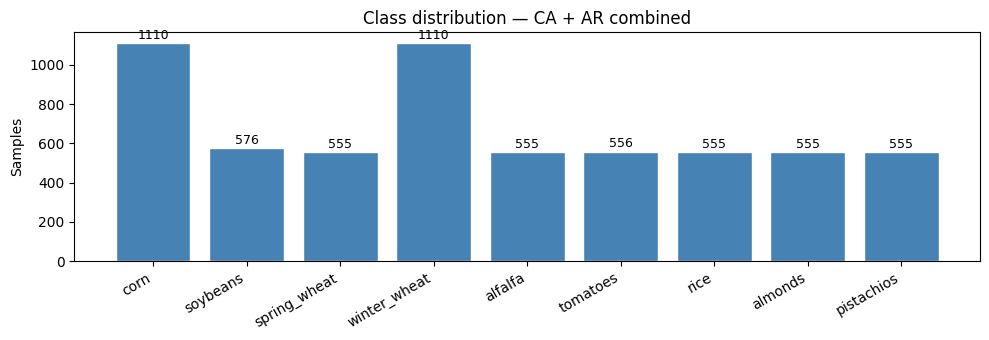

Total samples: 6127


In [ ]:
# ── 3a. Class distribution ──────────────────────────────────────────────────
import numpy as np, matplotlib.pyplot as plt
from collections import Counter

# Count samples per class and plot the distribution
counts        = Counter(y_raw.tolist())
labels_sorted = sorted(counts.keys())
names_sorted  = [CLASS_NAMES[i] for i in labels_sorted]
freqs         = [counts[i] for i in labels_sorted]

plt.figure(figsize=(10, 3.5))
bars = plt.bar(names_sorted, freqs, color='steelblue', edgecolor='white')
for bar, f in zip(bars, freqs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             str(f), ha='center', va='bottom', fontsize=9)
plt.title('Class distribution — CA + AR combined')
plt.ylabel('Samples')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(f'Total samples: {N}')


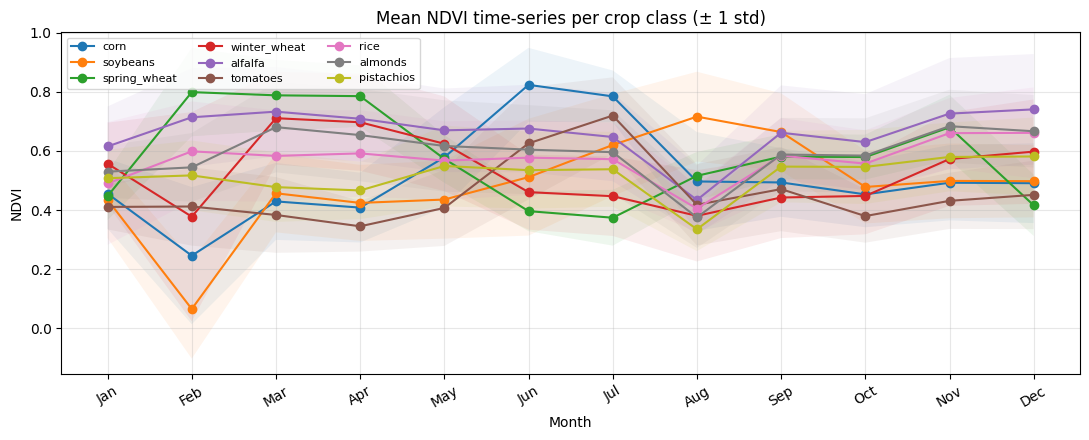

In [ ]:
# ── 3b. Per-class mean NDVI time-series (with ±1 std band) ─────────────────
import numpy as np, matplotlib.pyplot as plt

# NDVI = (NIR - RED) / (NIR + RED)
RED_IDX = S2_BANDS.index('B4')   # 2
NIR_IDX = S2_BANDS.index('B8')   # 3

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

# Plot mean NDVI time-series with ±1 std shaded area for each class
plt.figure(figsize=(11, 4.5))
for cls_idx in labels_sorted:
    mask  = (y_raw == cls_idx)
    X_cls = X_raw[mask]
    nir   = X_cls[:, :, NIR_IDX]
    red   = X_cls[:, :, RED_IDX]
    ndvi  = (nir - red) / (nir + red + 1e-6)
    mu    = ndvi.mean(axis=0)
    sig   = ndvi.std(axis=0)
    x     = range(1, 13)
    plt.plot(x, mu, marker='o', label=CLASS_NAMES[cls_idx])
    plt.fill_between(x, mu - sig, mu + sig, alpha=0.08)

plt.title('Mean NDVI time-series per crop class (± 1 std)')
plt.xlabel('Month')
plt.ylabel('NDVI')
plt.xticks(range(1, 13), month_labels, rotation=30)
plt.legend(loc='upper left', ncol=3, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


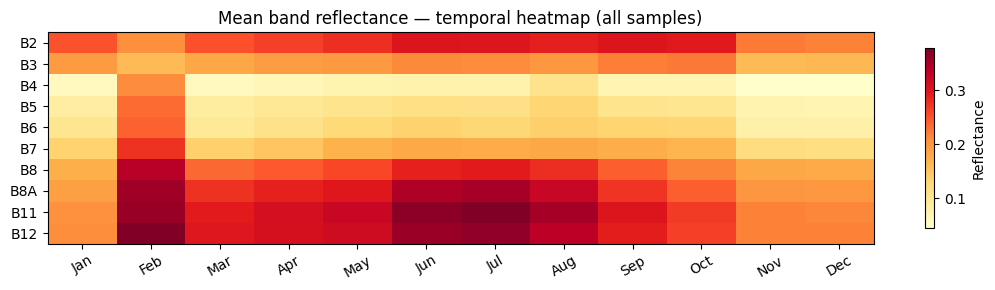

In [ ]:
# ── 3c. Temporal band-mean heatmap ──────────────────────────────────────────
import numpy as np, matplotlib.pyplot as plt

# Compute mean reflectance per band and month across all samples
band_month_mean = X_raw.mean(axis=0).T    # (C, T)

fig, ax = plt.subplots(figsize=(11, 3))
im = ax.imshow(band_month_mean, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(C))
ax.set_yticklabels(S2_BANDS[:C])
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels, rotation=30)
ax.set_title('Mean band reflectance — temporal heatmap (all samples)')
plt.colorbar(im, ax=ax, shrink=0.85, label='Reflectance')
plt.tight_layout()
plt.show()


In [ ]:
# ── 3d. Missing-value & noise inspection ────────────────────────────────────
import numpy as np

# Check for zero, NaN, and negative values in the raw feature array
zero_frac = (X_raw == 0).mean()
nan_frac  = np.isnan(X_raw).mean()
neg_frac  = (X_raw < 0).mean()

print(f'Zero-value fraction  : {zero_frac:.3%}')
print(f'NaN fraction         : {nan_frac:.3%}')
print(f'Negative-value frac. : {neg_frac:.3%}')

# Samples with at least one fully-zero time-step (cloud-filled composite)
all_zero_mask = (X_raw == 0).all(axis=2)
bad_samples   = all_zero_mask.any(axis=1).sum()
print(f'\nSamples with ≥1 fully-zero time-step: {bad_samples}/{N} ({bad_samples/N:.1%})')


Zero-value fraction  : 0.003%
NaN fraction         : 0.000%
Negative-value frac. : 0.000%

Samples with ≥1 fully-zero time-step: 0/6127 (0.0%)


---
## Step 4 · Data Preprocessing

Applies the full preprocessing pipeline:
1. Linear interpolation of missing/zero time-steps
2. Extraction of vegetation indices (NDVI, EVI, SAVI)
3. Feature concatenation (6 spectral + 3 VI = 9 channels)
4. Per-band min-max normalisation


In [ ]:
# ── 4a. Linear interpolation of missing time-steps ──────────────────────────
import numpy as np

# Simple linear interpolation along the time axis for fully-zero time-steps.
def interpolate_zeros(X):
    """Replace fully-zero time-steps with linear interpolation along T axis."""
    X_out = X.copy()
    for n in range(X_out.shape[0]):
        for c in range(X_out.shape[2]):
            series = X_out[n, :, c]
            zero_t = np.where(series == 0)[0]
            if len(zero_t) == 0 or len(zero_t) == len(series):
                continue
            ok_t = np.where(series != 0)[0]
            series[zero_t] = np.interp(zero_t, ok_t, series[ok_t])
            X_out[n, :, c] = series
    return X_out

# Apply interpolation and check the new zero fraction
X_interp = interpolate_zeros(X_raw)
print(f'After interpolation — remaining zero fraction: {(X_interp == 0).mean():.3%}')


After interpolation — remaining zero fraction: 0.000%


In [15]:
# ── 4b. Vegetation index extraction (NDVI, EVI, SAVI) ───────────────────────
import numpy as np

BLUE_IDX = S2_BANDS.index('B2')
RED_IDX  = S2_BANDS.index('B4')
NIR_IDX  = S2_BANDS.index('B8')

blue = X_interp[:, :, BLUE_IDX]
red  = X_interp[:, :, RED_IDX]
nir  = X_interp[:, :, NIR_IDX]

ndvi = (nir - red) / (nir + red + 1e-6)
evi  = np.clip(2.5 * (nir - red) / (nir + 6*red - 7.5*blue + 1 + 1e-6), -1, 1)
savi = (1 + 0.5) * (nir - red) / (nir + red + 0.5 + 1e-6)   # L = 0.5

# Concatenate VI channels → (N, T, 9)
X_vi = np.concatenate([
    X_interp,
    ndvi[..., np.newaxis],
    evi[..., np.newaxis],
    savi[..., np.newaxis],
], axis=2)

C_vi          = X_vi.shape[2]   # 9
BANDS_EXTENDED = S2_BANDS[:C] + ['NDVI', 'EVI', 'SAVI']
print(f'Channels after VI extraction: {C_vi}  {BANDS_EXTENDED}')


Channels after VI extraction: 13  ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12', 'NDVI', 'EVI', 'SAVI']


In [16]:
# ── 4c. Alignment check & min-max normalisation ──────────────────────────────
import numpy as np

assert X_vi.shape[0] == y_raw.shape[0], "Sample-label count mismatch!"

# Per-sample normalization: (x - min) / (max - min) calculated for each individual pixel
X_min = X_vi.min(axis=1, keepdims=True) # Min across the time dimension
X_max = X_vi.max(axis=1, keepdims=True)
X_norm = (X_vi - X_min) / (X_max - X_min + 1e-8)

print(f'Preprocessed shape  : {X_norm.shape}  (N={N}, T={T}, C={C_vi})')
print(f'Value range         : [{X_norm.min():.4f}, {X_norm.max():.4f}]')


Preprocessed shape  : (6127, 12, 13)  (N=6127, T=12, C=13)
Value range         : [0.0000, 1.0000]


---
## Step 5 · Model Implementation, Training & Comparison

Re-implements MCTNet, trains on CA+AR data, evaluates with OA / macro-F1 / Kappa,
and compares results against those reported in the paper.


In [17]:
# ── 5a. DataLoaders ──────────────────────────────────────────────────────────
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split

SEQ_LEN     = X_norm.shape[1]
IN_CHANNELS = X_norm.shape[2]
NUM_CLASSES = len(np.unique(y_raw))

X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_tensor = torch.tensor(y_raw,  dtype=torch.long)

full_dataset = TensorDataset(X_tensor, y_tensor)

train_size   = int(0.8 * len(full_dataset))
test_size    = len(full_dataset) - train_size

train_ds, test_ds = random_split(
    full_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

print(f'Train / Test Samples: {train_size} / {test_size}')
print(f'Input shape (T, C)  : ({SEQ_LEN}, {IN_CHANNELS})')
print(f'Number of Classes   : {NUM_CLASSES}')

Train / Test Samples: 4901 / 1226
Input shape (T, C)  : (12, 13)
Number of Classes   : 9


In [18]:
# ── 5b. MCTNet architecture ──────────────────────────────────────────────────
import torch
import torch.nn as nn

class ALPE(nn.Module):
    """Attention-based Learnable Positional Encoding"""
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.pos_embed = nn.Parameter(torch.zeros(1, seq_len, d_model))

    def forward(self, x):
        return x + self.pos_embed

class MCTNetStage(nn.Module):
    def __init__(self, in_c, out_c, seq_len, n_head=5):
        super().__init__()
        # CNN Sub-module: 2 Conv + BN + ReLU + Shortcut
        self.conv_block = nn.Sequential(
            nn.Conv1d(in_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_c),
            nn.ReLU(),
            nn.Conv1d(out_c, out_c, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_c)
        )
        self.shortcut = nn.Conv1d(in_c, out_c, kernel_size=1) if in_c != out_c else nn.Identity()
        self.relu = nn.ReLU()

        # Transformer Sub-module
        self.alpe = ALPE(seq_len, out_c)
        self.transformer = nn.TransformerEncoderLayer(
            d_model=out_c, nhead=n_head, dim_feedforward=out_c*2, batch_first=True
        )
        self.pool = nn.MaxPool1d(2)

    def forward(self, x):
        # CNN with Shortcut
        res = self.shortcut(x)
        x = self.relu(self.conv_block(x) + res)

        # Transformer (expects B, T, C)
        x = x.permute(0, 2, 1)
        x = self.alpe(x)
        x = self.transformer(x)

        # Back to (B, C, T) for Pooling
        x = x.permute(0, 2, 1)
        x = self.pool(x)
        return x

class MCTNet(nn.Module):
    def __init__(self, in_channels=13, num_classes=9, seq_len=12):
        super().__init__()
        # Stage 1: 10 bands + 3 VI = 13 channels
        self.stage1 = MCTNetStage(in_channels, 64, seq_len, n_head=4) # Use 4 heads if 64 isn't div by 5
        self.stage2 = MCTNetStage(64, 128, seq_len // 2, n_head=4)
        self.stage3 = MCTNetStage(128, 256, seq_len // 4, n_head=4)

        final_t = seq_len // 8
        self.classifier = nn.Sequential(
            nn.AdaptiveMaxPool1d(1), # Global Max Pooling as per paper
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1).float() # (B, C, T)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        return self.classifier(x)

In [22]:
# ── 5c. Training loop ────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Hardware & Model Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate the model (MANDATORY: defines 'model' for the optimizer)
# We detect in_channels dynamically from X_norm (should be 13)
model = MCTNet(
    in_channels=X_norm.shape[2],
    num_classes=len(np.unique(y_raw)),
    seq_len=12
).to(device)

print(f"Model instantiated on {device}")
print(f"Input channels: {X_norm.shape[2]} | Classes: {len(np.unique(y_raw))}")

# --- 2. Compute Class Weights ---
# Handles imbalance between common crops (Corn) and rarer ones (Tomatoes)
unique_classes = np.unique(y_raw)
weights = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_raw)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

# --- 3. Loss, Optimizer, and Scheduler ---
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# The paper trains for 200 epochs with LR decay
num_epochs = 200
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# --- 4. History tracking ---
history = {
    'loss': [], 'accuracy': [],
    'val_loss': [], 'val_accuracy': [],
    'lr': []
}

# --- 5. Training Loop ---
for epoch in range(num_epochs):
    # --- Training Phase ---
    model.train()
    total_train_loss = 0
    train_preds, train_true = [], []

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        preds = outputs.argmax(1).detach().cpu().numpy()
        train_preds.extend(preds)
        train_true.extend(y_batch.cpu().numpy())

    # Update Learning Rate
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)
    scheduler.step()

    # --- Evaluation Phase ---
    model.eval()
    all_preds, all_true = [], []
    total_val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)

            val_loss = criterion(outputs, y_batch)
            total_val_loss += val_loss.item()

            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(y_batch.cpu().numpy())

    # --- Metrics Calculation ---
    train_oa = accuracy_score(train_true, train_preds)
    oa    = accuracy_score(all_true, all_preds)
    f1    = f1_score(all_true, all_preds, average='macro')
    kappa = cohen_kappa_score(all_true, all_preds)

    history['loss'].append(total_train_loss / len(train_loader))
    history['accuracy'].append(train_oa)
    history['val_loss'].append(total_val_loss / len(test_loader))
    history['val_accuracy'].append(oa)

    # Print status every epoch
    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1:03d}/{num_epochs} | LR: {current_lr:.6f} | "
              f"Loss: {history['loss'][-1]:.4f} | Val OA: {oa:.4f} | F1: {f1:.4f}")

Model instantiated on cuda
Input channels: 13 | Classes: 9
Epoch 001/200 | LR: 0.001000 | Loss: 0.8585 | Val OA: 0.7773 | F1: 0.7759
Epoch 002/200 | LR: 0.001000 | Loss: 0.6229 | Val OA: 0.7928 | F1: 0.7872
Epoch 003/200 | LR: 0.001000 | Loss: 0.5676 | Val OA: 0.7945 | F1: 0.7905
Epoch 004/200 | LR: 0.000999 | Loss: 0.5245 | Val OA: 0.7977 | F1: 0.7926
Epoch 005/200 | LR: 0.000999 | Loss: 0.4784 | Val OA: 0.7977 | F1: 0.7923
Epoch 006/200 | LR: 0.000998 | Loss: 0.4558 | Val OA: 0.7847 | F1: 0.7804
Epoch 007/200 | LR: 0.000998 | Loss: 0.4296 | Val OA: 0.8197 | F1: 0.8147
Epoch 008/200 | LR: 0.000997 | Loss: 0.3722 | Val OA: 0.7928 | F1: 0.7894
Epoch 009/200 | LR: 0.000996 | Loss: 0.3711 | Val OA: 0.8018 | F1: 0.7958
Epoch 010/200 | LR: 0.000995 | Loss: 0.3494 | Val OA: 0.8034 | F1: 0.8010
Epoch 011/200 | LR: 0.000994 | Loss: 0.3187 | Val OA: 0.7912 | F1: 0.7858
Epoch 012/200 | LR: 0.000993 | Loss: 0.3176 | Val OA: 0.7953 | F1: 0.7905
Epoch 013/200 | LR: 0.000991 | Loss: 0.3008 | Val OA:

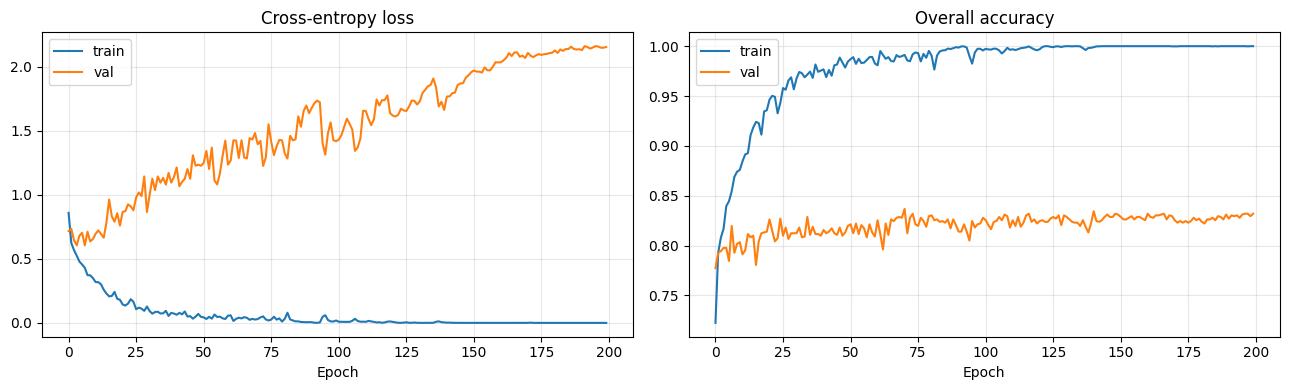

In [23]:
# ── 5d. Learning curves ──────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history['loss'],     label='train'); ax1.plot(history['val_loss'], label='val')
ax1.set_title('Cross-entropy loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=.3)

ax2.plot(history['accuracy'], label='train'); ax2.plot(history['val_accuracy'], label='val')
ax2.set_title('Overall accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=.3)

plt.tight_layout()
plt.show()


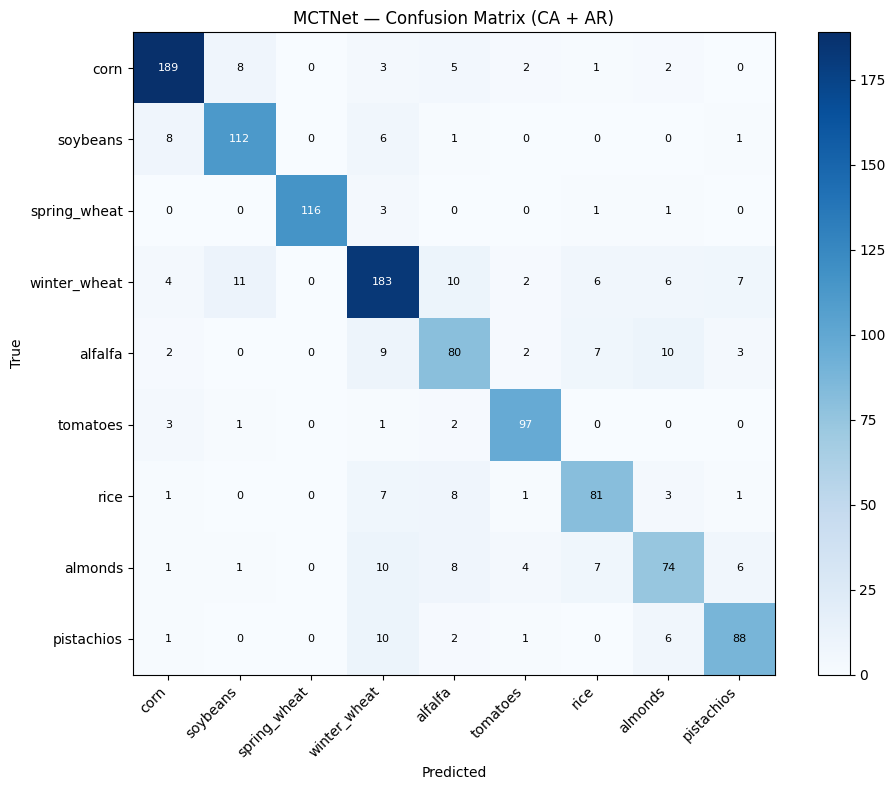

In [24]:
# ── 5e. Confusion matrix ─────────────────────────────────────────────────────
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        out = model(Xb.to(device))
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

y_pred = np.array(all_preds)
y_test = np.array(all_true)

present    = sorted(set(y_test.tolist()))
names_pres = [CLASS_NAMES[i] for i in present]
cm         = confusion_matrix(y_test, y_pred, labels=present)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(names_pres))); ax.set_xticklabels(names_pres, rotation=45, ha='right')
ax.set_yticks(range(len(names_pres))); ax.set_yticklabels(names_pres)
for i in range(len(names_pres)):
    for j in range(len(names_pres)):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.title('MCTNet — Confusion Matrix (CA + AR)')
plt.tight_layout()
plt.show()


In [25]:
# ── 5f. Classification report ────────────────────────────────────────────────
import numpy as np
from sklearn.metrics import classification_report

print('Classification Report\n')
print(classification_report(y_test, y_pred,
      labels=present, target_names=names_pres, zero_division=0))
print(f'Overall Accuracy : {np.mean(y_pred == y_test):.4f}')


Classification Report

              precision    recall  f1-score   support

        corn       0.90      0.90      0.90       210
    soybeans       0.84      0.88      0.86       128
spring_wheat       1.00      0.96      0.98       121
winter_wheat       0.79      0.80      0.79       229
     alfalfa       0.69      0.71      0.70       113
    tomatoes       0.89      0.93      0.91       104
        rice       0.79      0.79      0.79       102
     almonds       0.73      0.67      0.69       111
  pistachios       0.83      0.81      0.82       108

    accuracy                           0.83      1226
   macro avg       0.83      0.83      0.83      1226
weighted avg       0.83      0.83      0.83      1226

Overall Accuracy : 0.8320


---
## Save model to Google Drive

In [27]:
import os, torch
from google.colab import drive

save_dir = '/content/drive/MyDrive/crop_data'
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), f'{save_dir}/mctnet_model.pth')
print('Model saved ✅')


Model saved ✅
